In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10

In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)

print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 1)
Testing Images  : (10000, 32, 32, 3)
Testing Labels  : (10000, 1)


In [6]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

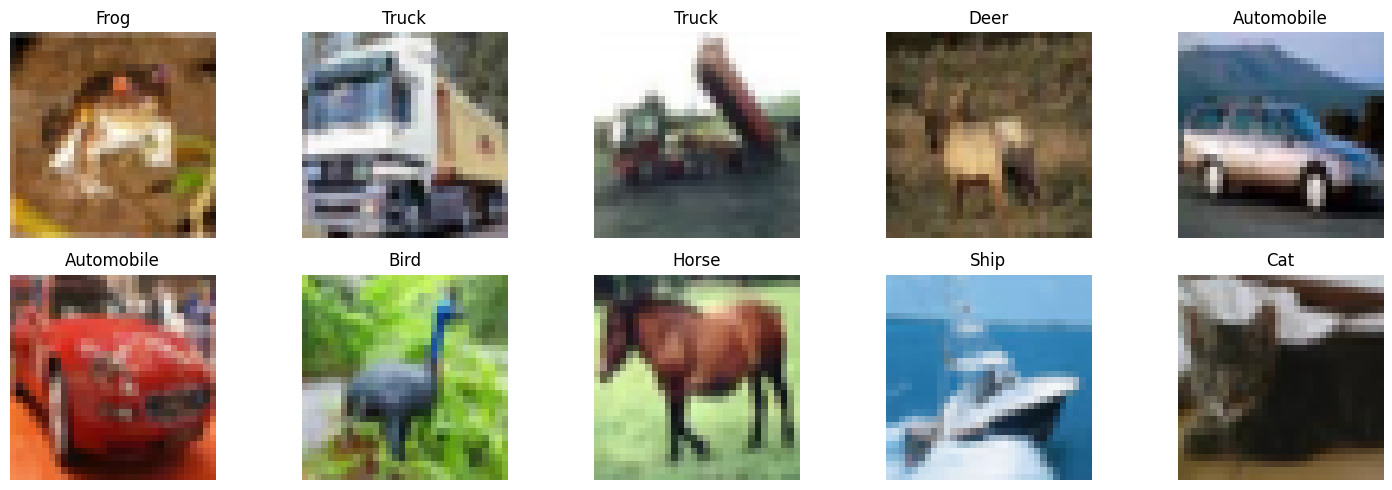

In [30]:
plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("figures/training_samples.pdf",
            format="pdf", dpi=600, bbox_inches="tight")
plt.show()

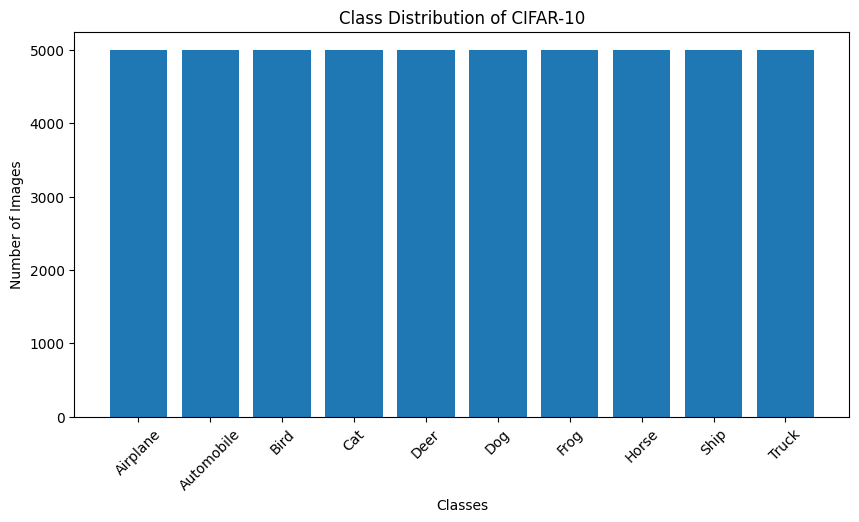

In [14]:
labels = y_train.flatten()

classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Class Distribution of CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.savefig("figures/class_distribution.eps",
            format="eps", dpi=600, bbox_inches="tight")
plt.show()

Image shape: (32, 32, 3)


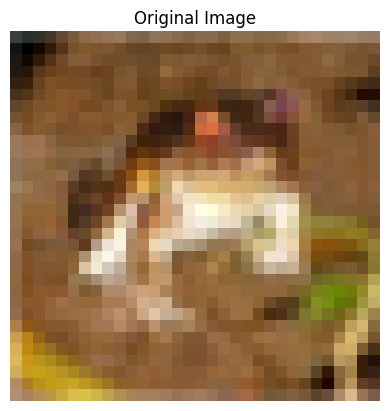

In [13]:
image = X_train[0]

print("Image shape:", image.shape)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [8]:
# Convert image from uint8 to float32
image_input = np.expand_dims(X_train[0].astype("float32"), axis=0)

print("Input shape:", image_input.shape)
print("Input data type:", image_input.dtype)

Input shape: (1, 32, 32, 3)
Input data type: float32


In [9]:
conv3 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=1,
    padding='valid'
)

output3 = conv3(image_input)

print("3×3 Kernel Feature Map Shape:", output3.shape)

3×3 Kernel Feature Map Shape: (1, 30, 30, 16)


In [10]:
conv5 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=5,
    strides=1,
    padding='valid'
)

output5 = conv5(image_input)

print("5×5 Kernel Feature Map Shape:", output5.shape)

5×5 Kernel Feature Map Shape: (1, 28, 28, 16)


In [11]:
conv7 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=7,
    strides=1,
    padding='valid'
)

output7 = conv7(image_input)

print("7×7 Kernel Feature Map Shape:", output7.shape)

7×7 Kernel Feature Map Shape: (1, 26, 26, 16)


In [15]:
print("Original Image Shape :", image.shape)
print("3×3 Feature Map      :", output3.shape)
print("5×5 Feature Map      :", output5.shape)
print("7×7 Feature Map      :", output7.shape)

Original Image Shape : (32, 32, 3)
3×3 Feature Map      : (1, 30, 30, 16)
5×5 Feature Map      : (1, 28, 28, 16)
7×7 Feature Map      : (1, 26, 26, 16)


In [16]:
conv_s1 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=1,
    padding='valid'
)

output_s1 = conv_s1(image_input)

print("Stride = 1, Padding = Valid")
print("Output Shape:", output_s1.shape)

Stride = 1, Padding = Valid
Output Shape: (1, 30, 30, 16)


In [17]:
conv_s2 = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=2,
    padding='valid'
)

output_s2 = conv_s2(image_input)

print("Stride = 2, Padding = Valid")
print("Output Shape:", output_s2.shape)

Stride = 2, Padding = Valid
Output Shape: (1, 15, 15, 16)


In [18]:
conv_same = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=1,
    padding='same'
)

output_same = conv_same(image_input)

print("Stride = 1, Padding = Same")
print("Output Shape:", output_same.shape)

Stride = 1, Padding = Same
Output Shape: (1, 32, 32, 16)


In [19]:
conv_s2_same = tf.keras.layers.Conv2D(
    filters=16,
    kernel_size=3,
    strides=2,
    padding='same'
)

output_s2_same = conv_s2_same(image_input)

print("Stride = 2, Padding = Same")
print("Output Shape:", output_s2_same.shape)

Stride = 2, Padding = Same
Output Shape: (1, 16, 16, 16)


In [20]:
print("Stride = 1, Padding = Valid :", output_s1.shape)
print("Stride = 2, Padding = Valid :", output_s2.shape)
print("Stride = 1, Padding = Same  :", output_same.shape)
print("Stride = 2, Padding = Same  :",output_s2_same.shape)

Stride = 1, Padding = Valid : (1, 30, 30, 16)
Stride = 2, Padding = Valid : (1, 15, 15, 16)
Stride = 1, Padding = Same  : (1, 32, 32, 16)
Stride = 2, Padding = Same  : (1, 16, 16, 16)


Feature Map Shape: (30, 30, 16)


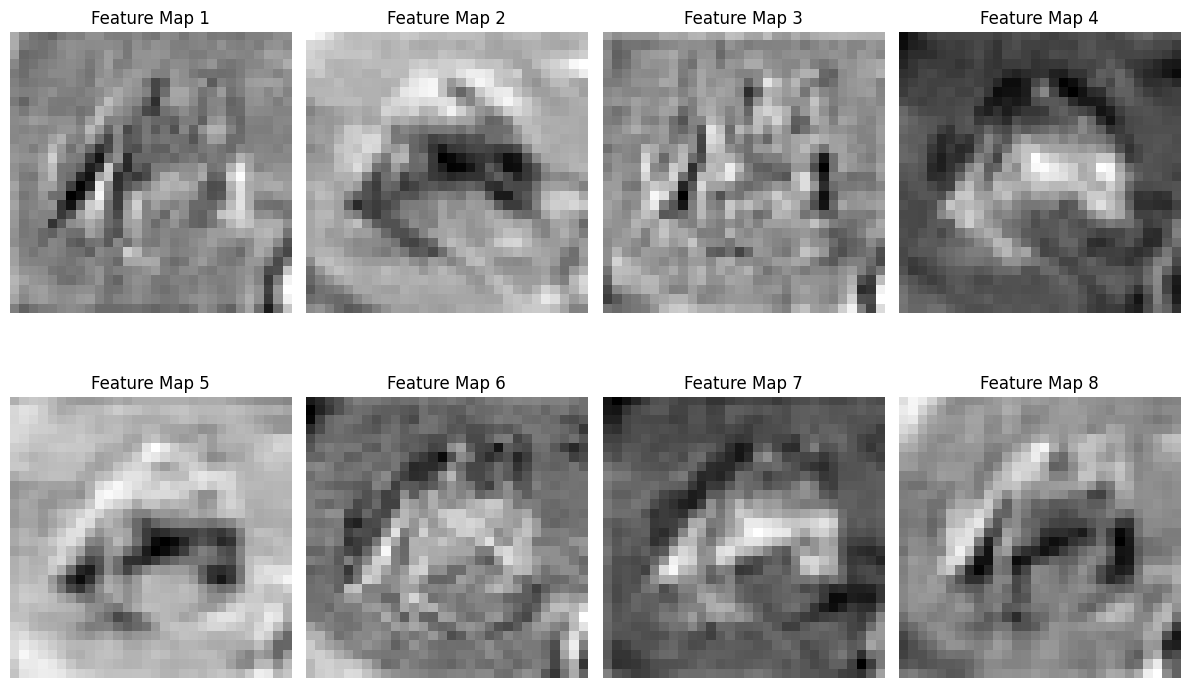

In [31]:
feature_maps = output3[0]
print("Feature Map Shape:", feature_maps.shape)

plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap='gray')
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("figures/feature_maps.pdf",
            format="pdf", dpi=600, bbox_inches="tight")
plt.show()

In [21]:
max_pool = tf.keras.layers.MaxPooling2D(
    pool_size=2,
    strides=2
)
max_output = max_pool(output3)
print("Max Pooling Output Shape:", max_output.shape)

Max Pooling Output Shape: (1, 15, 15, 16)


In [22]:
avg_pool = tf.keras.layers.AveragePooling2D(
    pool_size=2,
    strides=2
)
avg_output = avg_pool(output3)
print("Average Pooling Output Shape:", avg_output.shape)

Average Pooling Output Shape: (1, 15, 15, 16)


Original Feature Map : (1, 30, 30, 16)
Max Pooling          : (1, 15, 15, 16)
Average Pooling      : (1, 15, 15, 16)


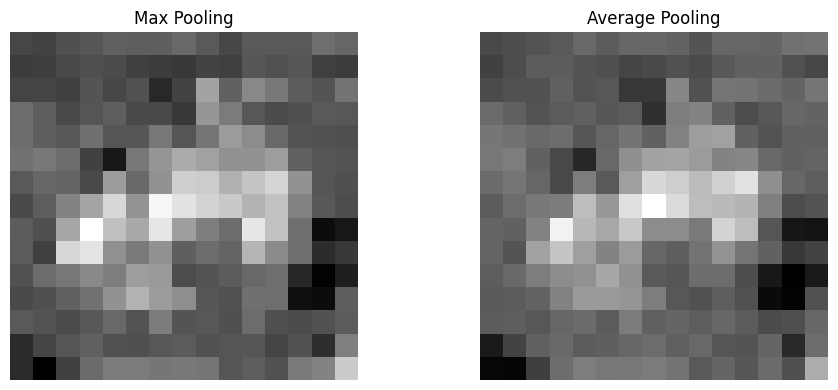

In [23]:
print("Original Feature Map :", output3.shape)
print("Max Pooling          :", max_output.shape)
print("Average Pooling      :", avg_output.shape)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(max_output[0, :, :, 0], cmap='gray')
plt.title("Max Pooling")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(avg_output[0, :, :, 0], cmap='gray')
plt.title("Average Pooling")
plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

C:\Users\asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 64ms/step - accuracy: 0.4044 - loss: 2.1602 - val_accuracy: 0.5026 - val_loss: 1.4051
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 62ms/step - accuracy: 0.5504 - loss: 1.2731 - val_accuracy: 0.5773 - val_loss: 1.2173
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.6098 - loss: 1.0993 - val_accuracy: 0.5988 - val_loss: 1.1469
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 97s 73ms/step - accuracy: 0.6528 - loss: 0.9843 - val_accuracy: 0.6076 - val_loss: 1.1721
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 119s 55ms/step - accuracy: 0.6895 - loss: 0.8850 - val_accuracy: 0.5992 - val_loss: 1.1861
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.7221 - loss: 0.7980 - val_accuracy: 0.6278 - val_loss: 1.1730
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - accuracy: 0.7541 - loss: 0.7063 - val_accuracy: 0.6194 - val_loss: 1.2127
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.7799 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


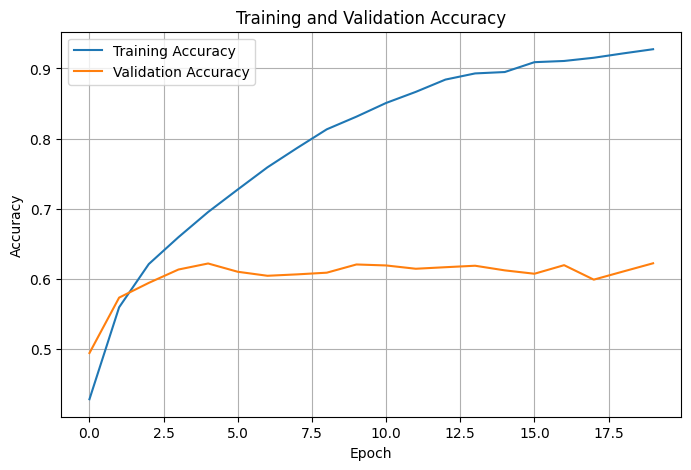

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')

plt.legend()
plt.grid(True)
plt.savefig("figures/training_validation_accuracy.eps",
            format="eps", dpi=600, bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


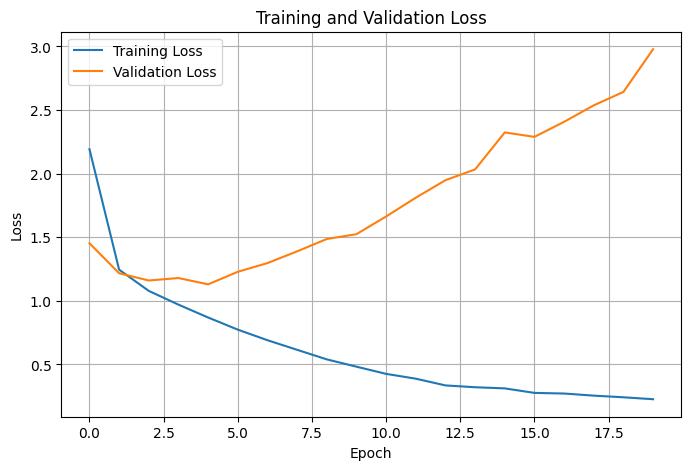

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.legend()
plt.grid(True)
plt.savefig("figures/training_validation_loss.eps",
            format="eps", dpi=600, bbox_inches="tight")
plt.show()

In [29]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

print(f"Test Accuracy(In percentage): {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6161 - loss: 3.0404
Test Loss: 3.0403528213500977
Test Accuracy: 0.616100013256073
Test Accuracy(In percentage): 61.61%


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

print("Predicted labels shape:", y_pred.shape)
print("True labels shape:", y_true.shape)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted labels shape: (10000,)
True labels shape: (10000,)
Accuracy  : 0.5742
Precision : 0.5837
Recall    : 0.5742
F1-Score  : 0.5724


In [31]:
print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.62      0.69      0.65      1000
  Automobile       0.75      0.74      0.75      1000
        Bird       0.50      0.47      0.49      1000
         Cat       0.41      0.45      0.43      1000
        Deer       0.57      0.55      0.56      1000
         Dog       0.50      0.54      0.52      1000
        Frog       0.65      0.70      0.68      1000
       Horse       0.67      0.66      0.67      1000
        Ship       0.78      0.72      0.75      1000
       Truck       0.76      0.64      0.70      1000

    accuracy                           0.62     10000
   macro avg       0.62      0.62      0.62     10000
weighted avg       0.62      0.62      0.62     10000



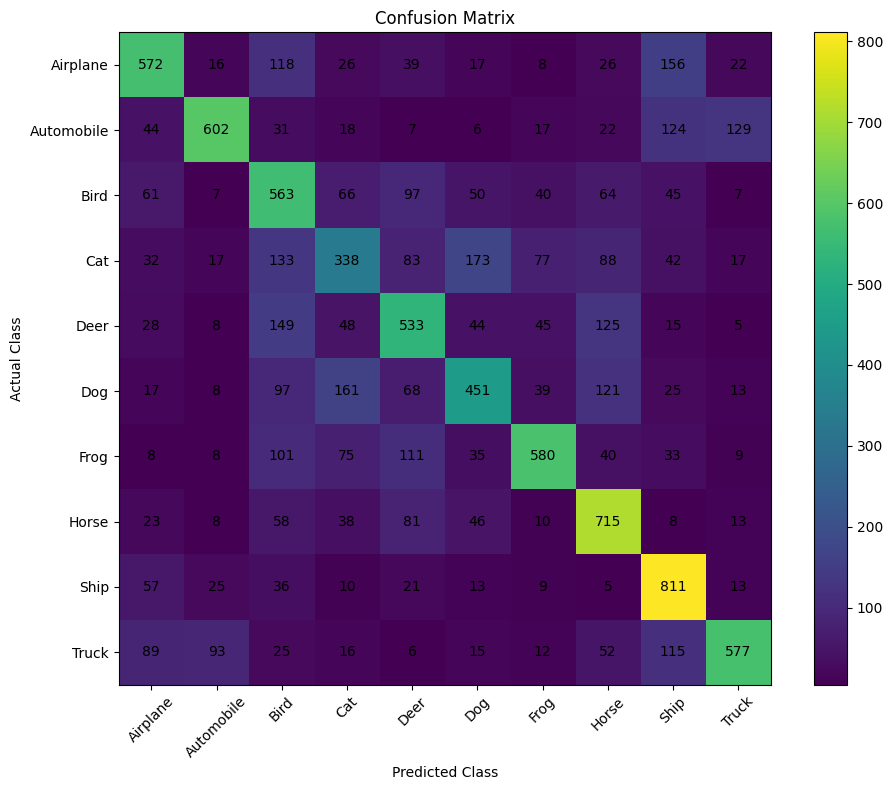

In [32]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha='center',
                 va='center')

plt.colorbar()
plt.tight_layout()
plt.savefig("figures/confusion_matrix.pdf",
            format="pdf", dpi=600, bbox_inches="tight")
plt.show()

In [33]:
print("\n========== FINAL RESULTS ==========")

print(f"Training Accuracy : {history.history['accuracy'][-1] * 100:.2f}%")
print(f"Validation Accuracy : {history.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Testing Accuracy : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


========== FINAL RESULTS ==========
Training Accuracy : 92.73%
Validation Accuracy : 62.26%
Testing Accuracy : 61.61%
Precision : 0.6219
Recall : 0.6161
F1-Score : 0.6178


In [34]:
import tensorflow as tf
import time

relu_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

relu_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

relu_history = relu_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

relu_time = time.time() - start

relu_loss, relu_accuracy = relu_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"ReLU Test Accuracy: {relu_accuracy * 100:.2f}%")
print(f"ReLU Training Time: {relu_time:.2f} seconds")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4584 - loss: 1.7940 - val_accuracy: 0.5419 - val_loss: 1.3057
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5933 - loss: 1.1596 - val_accuracy: 0.6063 - val_loss: 1.1392
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.6468 - loss: 1.0074 - val_accuracy: 0.6090 - val_loss: 1.1472
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.6923 - loss: 0.8839 - val_accuracy: 0.6164 - val_loss: 1.1407
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7245 - loss: 0.7817 - val_accuracy: 0.6158 - val_loss: 1.1902
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7595 - loss: 0.6857 - val_accuracy: 0.6389 - val_loss: 1.1659
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7914 - loss: 0.5976 - val_accuracy: 0.6306 - val_loss: 1.2558
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8087 -

In [35]:
sigmoid_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='sigmoid',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='sigmoid',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='sigmoid'),

    tf.keras.layers.Dense(10, activation='softmax')
])

sigmoid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

sigmoid_history = sigmoid_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

sigmoid_time = time.time() - start

sigmoid_loss, sigmoid_accuracy = sigmoid_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Sigmoid Test Accuracy: {sigmoid_accuracy * 100:.2f}%")
print(f"Sigmoid Training Time: {sigmoid_time:.2f} seconds")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.3618 - loss: 1.7348 - val_accuracy: 0.4754 - val_loss: 1.4403
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.5131 - loss: 1.3561 - val_accuracy: 0.5239 - val_loss: 1.2994
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5746 - loss: 1.1943 - val_accuracy: 0.5836 - val_loss: 1.1595
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6098 - loss: 1.0936 - val_accuracy: 0.6069 - val_loss: 1.1094
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6413 - loss: 1.0131 - val_accuracy: 0.6133 - val_loss: 1.1077
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6722 - loss: 0.9311 - val_accuracy: 0.6369 - val_loss: 1.0235
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.6992 - loss: 0.8550 - val_accuracy: 0.6416 - val_loss: 1.0286
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7287 -

In [36]:
print("\n========== ReLU vs Sigmoid ==========")

print(f"ReLU Test Accuracy     : {relu_accuracy * 100:.2f}%")
print(f"Sigmoid Test Accuracy  : {sigmoid_accuracy * 100:.2f}%")

print(f"ReLU Training Time     : {relu_time:.2f} seconds")
print(f"Sigmoid Training Time  : {sigmoid_time:.2f} seconds")


========== ReLU vs Sigmoid ==========
ReLU Test Accuracy     : 61.53%
Sigmoid Test Accuracy  : 64.31%
ReLU Training Time     : 308.71 seconds
Sigmoid Training Time  : 339.93 seconds


In [37]:
max_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

max_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

max_history = max_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

max_time = time.time() - start

max_loss, max_accuracy = max_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Max Pooling Test Accuracy: {max_accuracy * 100:.2f}%")
print(f"Max Pooling Training Time: {max_time:.2f} seconds")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3954 - loss: 2.2684 - val_accuracy: 0.4775 - val_loss: 1.4638
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.5522 - loss: 1.2669 - val_accuracy: 0.5638 - val_loss: 1.2574
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6152 - loss: 1.0933 - val_accuracy: 0.5838 - val_loss: 1.2016
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6581 - loss: 0.9772 - val_accuracy: 0.5908 - val_loss: 1.2384
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.7003 - loss: 0.8575 - val_accuracy: 0.5956 - val_loss: 1.2400
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7349 - loss: 0.7545 - val_accuracy: 0.6189 - val_loss: 1.2183
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7706 - loss: 0.6570 - val_accuracy: 0.6142 - val_loss: 1.2872
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7965 -

In [38]:
avg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.AveragePooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.AveragePooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

avg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

avg_history = avg_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

avg_time = time.time() - start

avg_loss, avg_accuracy = avg_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Average Pooling Test Accuracy: {avg_accuracy * 100:.2f}%")
print(f"Average Pooling Training Time: {avg_time:.2f} seconds")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.4543 - loss: 2.0592 - val_accuracy: 0.5511 - val_loss: 1.2795
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.5969 - loss: 1.1550 - val_accuracy: 0.5986 - val_loss: 1.1663
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.6553 - loss: 0.9868 - val_accuracy: 0.6221 - val_loss: 1.1193
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7017 - loss: 0.8521 - val_accuracy: 0.6090 - val_loss: 1.1827
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.7448 - loss: 0.7281 - val_accuracy: 0.6319 - val_loss: 1.1342
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.7840 - loss: 0.6192 - val_accuracy: 0.6325 - val_loss: 1.2294
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8206 - loss: 0.5170 - val_accuracy: 0.6413 - val_loss: 1.2759
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8514 -

In [39]:
print("\n========== Max Pooling vs Average Pooling ==========")

print(f"Max Pooling Accuracy     : {max_accuracy * 100:.2f}%")
print(f"Average Pooling Accuracy : {avg_accuracy * 100:.2f}%")

print(f"Max Pooling Time         : {max_time:.2f} seconds")
print(f"Average Pooling Time     : {avg_time:.2f} seconds")


========== Max Pooling vs Average Pooling ==========
Max Pooling Accuracy     : 61.58%
Average Pooling Accuracy : 62.18%
Max Pooling Time         : 392.29 seconds
Average Pooling Time     : 486.61 seconds


In [40]:
model_16 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        16, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        16, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_16.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_16 = model_16.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

time_16 = time.time() - start

loss_16, accuracy_16 = model_16.evaluate(
    X_test,
    y_test,
    verbose=0
)

params_16 = model_16.count_params()

print(f"16 Filters Accuracy : {accuracy_16 * 100:.2f}%")
print(f"16 Filters Time     : {time_16:.2f} seconds")
print(f"16 Filters Parameters: {params_16:,}")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3165 - loss: 2.3919 - val_accuracy: 0.3989 - val_loss: 1.6346
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.4394 - loss: 1.5444 - val_accuracy: 0.4623 - val_loss: 1.4880
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.5041 - loss: 1.3850 - val_accuracy: 0.4709 - val_loss: 1.5536
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.5532 - loss: 1.2578 - val_accuracy: 0.5340 - val_loss: 1.3532
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5939 - loss: 1.1495 - val_accuracy: 0.5533 - val_loss: 1.3535
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6270 - loss: 1.0603 - val_accuracy: 0.5387 - val_loss: 1.4169
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6552 - loss: 0.9802 - val_accuracy: 0.5413 - val_loss: 1.4013
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.6793 - loss:

In [43]:
model_64 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same'
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        strides=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

model_64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()

history_64 = model_64.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

time_64 = time.time() - start

loss_64, accuracy_64 = model_64.evaluate(
    X_test,
    y_test,
    verbose=0
)

params_64 = model_64.count_params()

print(f"64 Filters Accuracy : {accuracy_64 * 100:.2f}%")
print(f"64 Filters Time     : {time_64:.2f} seconds")
print(f"64 Filters Parameters: {params_64:,}")

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 118s 93ms/step - accuracy: 0.3635 - loss: 2.0527 - val_accuracy: 0.4553 - val_loss: 1.5147
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.5038 - loss: 1.3969 - val_accuracy: 0.5428 - val_loss: 1.3199
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.5786 - loss: 1.2017 - val_accuracy: 0.5744 - val_loss: 1.2322
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.6299 - loss: 1.0571 - val_accuracy: 0.5945 - val_loss: 1.1831
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 122s 97ms/step - accuracy: 0.6693 - loss: 0.9427 - val_accuracy: 0.6146 - val_loss: 1.1784
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 137s 110ms/step - accuracy: 0.7057 - loss: 0.8529 - val_accuracy: 0.6353 - val_loss: 1.1133
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 132s 101ms/step - accuracy: 0.7336 - loss: 0.7625 - val_accuracy: 0.6292 - val_loss: 1.1644
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 144s 103ms/step - accurac

In [42]:
print("\n========== 16 vs 64 FILTERS ==========")

print(f"{'Metric':<25} {'16 Filters':>15} {'64 Filters':>15}")
print("-" * 55)

print(
    f"{'Test Accuracy':<25} "
    f"{accuracy_16 * 100:>14.2f}% "
    f"{accuracy_64 * 100:>14.2f}%"
)

print(
    f"{'Training Time (s)':<25} "
    f"{time_16:>15.2f} "
    f"{time_64:>15.2f}"
)

print(
    f"{'Parameters':<25} "
    f"{params_16:>15,} "
    f"{params_64:>15,}"
)


========== 16 vs 64 FILTERS ==========
Metric                         16 Filters      64 Filters
-------------------------------------------------------
Test Accuracy                      54.03%          60.02%
Training Time (s)                  273.11          706.04
Parameters                        135,258         564,426
